# Clustering Lab

 
Based of the amazing work you did in the Movie Industry you've been recruited to the NBA! You are working as the VP of Analytics that helps support a head scout, Mr. Rooney, for the worst team in the NBA probably the Wizards. Mr. Rooney just heard about Data Science and thinks it can solve all the team's problems!!! He wants you to figure out a way to find players that are high performing but maybe not highly paid that you can steal to get the team to the playoffs! 

In this document you will work through a similar process that we did in class with the NBA data (NBA_Perf_22 and nba_salaries_22), merging them together. This is from 22-23 season, feel free to update to 2023-24 season if you want.
# Data Sources:

https://www.basketball-reference.com/leagues/NBA_2024_totals.html # reference for performance data
https://www.basketball-reference.com/contracts/players.html # reference for salary data


Details: 

- Determine a way to use clustering to estimate based on performance if 
players are under or over paid, generally. 

- Then select players you believe would be best for your team and explain why. Do so in three categories: 
    * Examples that are not good choices (3 or 4) 
    * Several options that are good choices (3 or 4)
    * Several options that could work, assuming you can't get the players in the good category (3 or 4)

- You will decide the cutoffs for each category, so you should be able to explain why you chose them.

- Provide a well commented and clean report of your findings in a separate notebook that can be presented to Mr. Rooney, keeping in mind he doesn't understand...anything. Include a rationale for variables you included in the model, details on your approach and a overview of the results with supporting visualizations. 


Hints:

- Salary is the variable you are trying to understand 
- When interpreting you might want to use graphs that include variables that are the most correlated with Salary
- You'll need to scale the variables before performing the clustering
- Be specific about why you selected the players that you did, more detail is better
- Use good coding practices, comment heavily, indent, don't use for loops unless totally necessary and create modular sections that align with some outcome. If necessary create more than one script,list/load libraries at the top and don't include libraries that aren't used. 
- Be careful for non-traditional characters in the players names, certain graphs won't work when these characters are included.


In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

In [3]:
salaries = pd.read_csv('/workspaces/DS-3021/10_kMeans Clustering/bball_salary.csv')
performance = pd.read_csv('/workspaces/DS-3021/10_kMeans Clustering/performance.csv')

In [4]:
nba = pd.merge(salaries, performance, on='Player')

In [5]:
nba.columns

Index(['Rk_x', 'Player', 'Tm', '2024-25', '2025-26', '2026-27', '2027-28',
       '2028-29', '2029-30', 'Guaranteed', '-9999', 'Rk_y', 'Age', 'Team',
       'Pos', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P',
       '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST',
       'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Trp-Dbl', 'Awards',
       'Player-additional'],
      dtype='object')

In [6]:
nba['2024-25'] = nba['2024-25'].str.replace('$', '')
nba['2024-25'] = nba['2024-25'].astype('float64')

In [7]:
#Drop variables that will not be needed or are duplicates
nba = nba.drop(columns=['2025-26', '2026-27', '2027-28',
       '2028-29', '2029-30', 'Guaranteed', '-9999','Awards',
       'Player-additional'])

<Axes: >

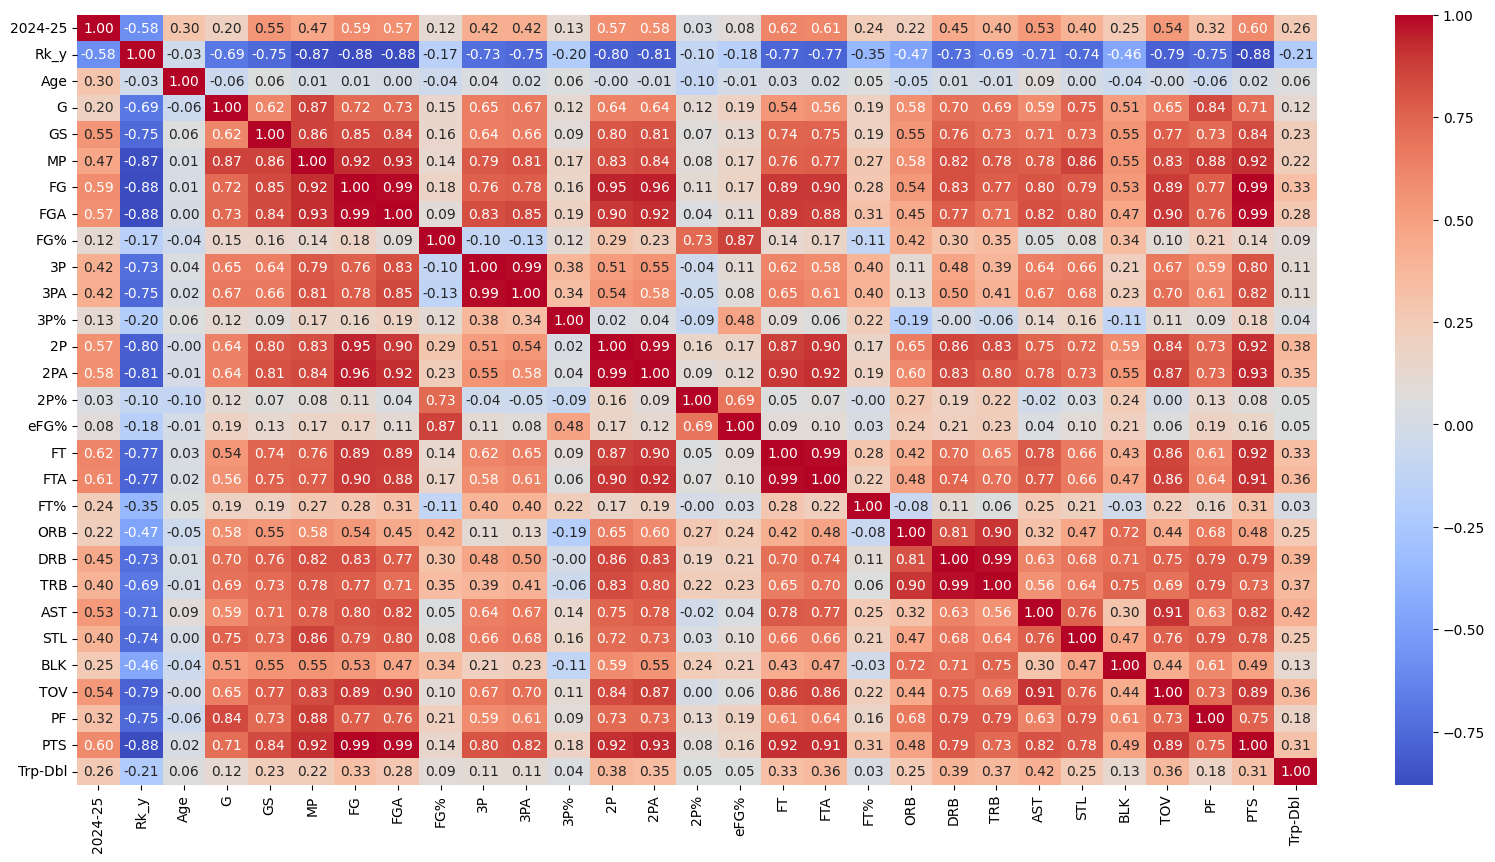

In [8]:
# make a heatmap to spot correlations
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
# Corrected code to create a heatmap of correlations for float64 columns
sns.heatmap(nba.select_dtypes(include='float64').corr(), annot=True, fmt='.2f', cmap='coolwarm')

In [9]:
nba = nba[['2024-25', 'Rk_y','2P', 'FT', 'PTS', 'DRB']]

<Axes: >

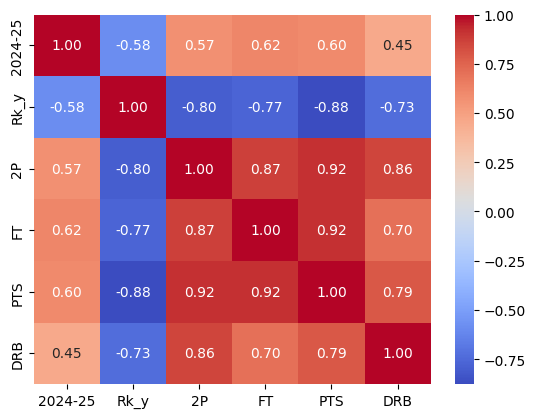

In [10]:
sns.heatmap(nba.select_dtypes(include='float64').corr(), annot=True, fmt='.2f', cmap='coolwarm')
#create a heatmap of the variables most correlated with salary

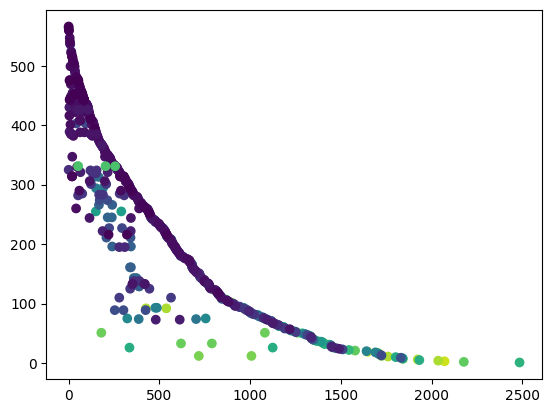

In [74]:
plt.scatter(nba['PTS'], nba['Rk_y'], c = nba['2024-25'])

In [75]:
#Run the clustering algo with your best guess for K

#Ideally, I think the algo should have 4 clusters- 
# Good players that are paid well,
# good players that aren't paid well, 
# bad players that aren't paid well, 
# bad players that aren't paid well

In [11]:
#standardize the data
scaler = MinMaxScaler()
nba[['PTS', 'Rk_y', '2P', 'FT', 'DRB']] = scaler.fit_transform(nba[['PTS', 'Rk_y', '2P', 'FT', 'DRB']])

In [12]:
#turn salary into a categorical variable
nba['salary_tier']= pd.qcut(nba['2024-25'], q=4, labels=['Low', 'Med-Low', 'Med-High', 'High'])

In [32]:
cluster_data = nba[['PTS', 'Rk_y', '2P', 'FT', 'DRB']]
kmeans_4 = KMeans(n_clusters=4, random_state=1).fit(cluster_data)

In [33]:
#View the results
print(kmeans_4.inertia_)
print(kmeans_4.cluster_centers_)

20.189542321317763
[[0.0407411  0.72683312 0.03135315 0.02045698 0.05548919]
 [0.15638155 0.42778851 0.11927305 0.08492614 0.18476442]
 [0.59070308 0.06271767 0.51248499 0.44554774 0.53432531]
 [0.3323439  0.2041755  0.25284312 0.1950505  0.31435231]]


In [34]:
px.scatter(nba, x='PTS', y='Rk_y', color = kmeans_4.labels_, symbol = 'salary_tier' )

In [55]:
#Create a visualization of the results with 2 or 3 variables that you think will best
#differentiate the clusters
fig = px.scatter_3d(nba, x="PTS", y="Rk_y", z="2024-25", color=kmeans_4.labels_)
fig.show(renderer="browser")

In [17]:
#Evaluate the quality of the clustering using total variance explained and silhouette scores
import numpy as np
from sklearn.metrics import silhouette_score

In [18]:
total_sum_squares = np.sum((cluster_data - np.mean(cluster_data))**2)
total = np.sum(total_sum_squares)
print(total)

150.8935048938118


/workspaces/DS-3021/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning:

The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)



In [19]:
between_SSE = (total-kmeans_4.inertia_)
print(between_SSE)
Var_explained = between_SSE/total
print(Var_explained)
#81 percent of variance explained! 

130.70396257249405
0.8662000572156785


In [20]:
print(silhouette_score(cluster_data, kmeans_4.labels_))
#Silhouette score of 0.43

0.4151990997929999


In [21]:
#Determine the ideal number of clusters using the elbow method and the silhouette coefficient
silhouette_scores = []
for k in range(2, 11):
    kmeans_obj = KMeans(n_clusters=k, algorithm="lloyd", random_state=1).fit(cluster_data)
    silhouette_scores.append(silhouette_score(cluster_data, kmeans_obj.labels_))

best_nc = silhouette_scores.index(max(silhouette_scores))+2
print("ideal number of clusters based on silhouette score:", best_nc)

ideal number of clusters based on silhouette score: 2


In [22]:
wcss = []
for i in range(1, 11):
    kmeans_k = KMeans(n_clusters=i, random_state=1).fit(cluster_data)
    wcss.append(kmeans_k.inertia_)

In [23]:
elbow_data_Dem = pd.DataFrame({"k": range(1, 11), "wcss": wcss})
fig = px.line(elbow_data_Dem, x="k", y="wcss", title="Elbow Method for Optimal k")
fig.update_layout(xaxis_title="Number of Clusters (k)", yaxis_title="Within-Cluster Sum of Squares (WCSS)")
fig

In [24]:
#Visualize the results of the elbow method
fig = go.Figure(data=go.Scatter(x=list(range(2, 11)), y=silhouette_scores))
fig

In [31]:
#Use the recommended number of cluster (assuming it's different) to retrain your model and visualize the results
kmeans_3 = KMeans(n_clusters=5, random_state=1).fit(cluster_data)

# Step 3: visualize plot
fig = px.scatter_3d(cluster_data, x="PTS", y="Rk_y", z="2024-25",color=kmeans_3.labels_,
                    title="Aye vs. Nay vs. Other votes for Democrat-introduced bills")
# add x for center of the cluster
fig.add_trace(go.Scatter3d(x=kmeans_3.cluster_centers_[:, 1], y=kmeans_3.cluster_centers_[:, 2],
                            z=kmeans_3.cluster_centers_[:, 0], mode="markers", marker=dict(size=20, color="black"),
                            name="Cluster Centers"))

fig

ValueError: Value of 'z' is not the name of a column in 'data_frame'. Expected one of ['PTS', 'Rk_y', '2P', 'FT', 'DRB'] but received: 2024-25

In [ ]:
#Once again evaluate the quality of the clustering using total variance explained and silhouette scores

In [ ]:
#Use the model to select players for Mr. Rooney to consider

#Write up the results in a separate notebook with supporting visualizations and 
an overview of how and why you made the choices you did. This should be at least 
500 words and should be written for a non-technical audience.